
##  Dry and Moist sumulations in Jovian EZ zone 

- Note: restart the jupyter kernel before rerunning, otherwise you will get a runtime error

In [1]:
#! /usr/bin/env python3
import numpy as np
import sys
import h5py

sys.path.append("../python")  # Adjust the path to build/python/
sys.path.append(".")

## load the necessary modules
from canoe import def_species, load_configure, index_map
from canoe.snap import def_thermo
from canoe.athena import Mesh, ParameterInput, Outputs, MeshBlock
from canoe.harp import radiation_band, radiation


In [2]:
# load the configuration file
pin = ParameterInput()
pin.load_from_file("juno_mwr.inp")
pin.set_boolean("job", "verbose", False)  

# register the speicies and thermodynamics
vapors = pin.get_string("species", "vapor").split(", ")
clouds = pin.get_string("species", "cloud").split(", ")
tracers = pin.get_string("species", "tracer").split(", ")

def_species(vapors=vapors, clouds=clouds, tracers=tracers)
def_thermo(pin)

# load bands and opacities
config = load_configure("juno_mwr.yaml")

Log, "2025-06-13 15:42:19",        canoe, 1., "Installing monitor canoe"
Log, "2025-06-13 15:42:19",        canoe, 1.1., "Initialize IndexMap"
Log, "2025-06-13 15:42:19",         snap, 3., "Installing monitor snap"
Log, "2025-06-13 15:42:19",         snap, 3.1., "Initialize Thermodynamics"
Log, "2025-06-13 15:42:19",         snap, 3.1.1., "Enrolling vapor functions"
Log, "2025-06-13 15:42:19",         snap, 3.1.1.1., "Enrolling H2O vapor pressures"
Log, "2025-06-13 15:42:19",         snap, 3.1.2.1., "Enrolling NH3 vapor pressures"


In [3]:
# set incident angles 
angle =[0.0, 15, 30.0, 45.]  # in degrees
angles = ' '.join([f"({x},)" for x in angle])
pin.set_string("radiation","outdir",angles)

print(pin.get_string("radiation","outdir"))

(0.0,) (15,) (30.0,) (45.0,)


In [4]:
# set the gravity 
pin.set_string("hydro", "grav_acc1", f"{-23.3}") # Equatorial zone
# pin.set_string("hydro", "grav_acc1", f"{-27.01}") # pole 

print("Gravity acceleration:", pin.get_string("hydro", "grav_acc1"))

Gravity acceleration: -23.3


In [5]:
# get index_map 
pindex = index_map.get_instance()
iNH3 = pindex.get_vapor_id("NH3")
iH2O = pindex.get_vapor_id("H2O")

print(f"iNH3 = {iNH3}, iH2O = {iH2O}")

P0 = pin.get_real("mesh", "ReferencePressure")
print(f"Reference Pressure: {P0} Pa")

iNH3 = 2, iH2O = 1
Reference Pressure: 100000.0 Pa


In [6]:
# set mesh; we use the 1st column of the 1st meshblock of the Athena++ mesh

nx2 = 1  # air column number, single column in this case
pin.set_string("mesh", "nx2", f"{nx2}")

# init the Mesh
mesh = Mesh(pin) 
mesh.initialize(pin)

# get the first meshblock
mb = mesh.meshblock(0)  

Log, "2025-06-13 15:42:33",         snap, 4.1., "Initialize Decomposition"
Log, "2025-06-13 15:42:33",         snap, 5.1., "Initialize ImplicitSolver"
Log, "2025-06-13 15:42:33", microphysics, 7., "Installing monitor microphysics"
Log, "2025-06-13 15:42:33", microphysics, 7.1., "Initialize Microphysics"
Log, "2025-06-13 15:42:33",         harp, 9., "Installing monitor harp"
Log, "2025-06-13 15:42:33",         harp, 9.1., "Initialize Radiation"
Log, "2025-06-13 15:42:33",         harp, 9.1.1., "Load Radiation bands from juno_mwr.yaml"
Log, "2025-06-13 15:42:33",         harp, 9.1.1.1., "Initialize RadiationBand CH1"
Log, "2025-06-13 15:42:33",      opacity, 9.1.1.2., "Installing monitor opacity"
Log, "2025-06-13 15:42:33",      opacity, 9.1.1.2.1., "Create Absorber CIA"
Log, "2025-06-13 15:42:33",      opacity, 9.1.1.3.1., "Create Absorber NH3"
Log, "2025-06-13 15:42:33",      opacity, 9.1.1.4.1., "Create Absorber H2O"
Log, "2025-06-13 15:42:33",      opacity, 9.1.1.5.1., "Create Absorb

In [7]:
## set EZ parameters

##  EZ abundances and temperature in Cheng (2020) 
xNH3=351     # deep-layer abundance, ppmv
xH2O=2500    # ppmv
T1bar=169    # 1-bar temperature, K

## use the first ap column of the block
Jindex=0   # Jindex ∈ [0, nx2-1]

## RH limit 
RHmax=1  # limit of relative humidity, 1 means 100%, only affects NH3 cloud-layer, set to 1 in EZ
maxiter=200  # do not change


In [8]:
## retrieve  bottom temperature Ts from 1bar temperature (Potential Temperature)

Ts=mb.retrieve_Ts_given_T1bar(pin,  xNH3,  T1bar, RHmax,  Jindex, "dry", xH2O, maxiter)

# then, you can build from the bottom with the bottom temperature Ts with:
# mb.construct_atmosphere_Ts(pin,  xNH3,  Ts,  RHmax,  Jindex, adiabate, xH2O) 


Log, "2025-06-13 15:42:38", pycanoe_construct_atmosphere, 18., "Installing monitor pycanoe_construct_atmosphere"


In [9]:

## ---------------    a moist adiabatic + uniform NH3  ---------------------------
adiabate="pseudo"

mb.construct_atmosphere_Ts(pin,  xNH3,  Ts,  RHmax,  Jindex, adiabate, xH2O) 

## calc for the Jindex_st column profile
aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)   
#### loop over layers bottom up
nlyr=len(aircolumn)             ## default 1600 pressure layers

moist_temp= np.array([0.0]*nlyr)      ## temperature, K
moist_theta= np.array([0.0]*nlyr)     ## potential temperature, K, reference pressure P0 = 1 bar

for i in range(nlyr): 
    moist_temp[i] = mb.get_temp(mb.k_st, mb.j_st + Jindex,i)    
    moist_theta[i] = mb.get_theta(P0, mb.k_st, mb.j_st + Jindex,i)


In [10]:
## ---------------    a dry adiabatic + uniform NH3  ---------------------------
adiabate="dry"

mb.construct_atmosphere_Ts(pin,  xNH3,  Ts,  RHmax,  Jindex, adiabate, xH2O) 

## calc for the Jindex_st column profile
aircolumn = mb.get_aircolumn(mb.k_st, mb.j_st + Jindex, mb.i_st, mb.i_ed)   
#### loop over layers bottom up
nlyr=len(aircolumn)             ## default 1600 pressure layers

dry_temp= np.array([0.0]*nlyr)      ## temperature, K
dry_theta= np.array([0.0]*nlyr)     ## potential temperature, K, reference pressure P0 = 1 bar

for i in range(nlyr): 
    dry_temp[i] = mb.get_temp(mb.k_st, mb.j_st + Jindex,i)    
    dry_theta[i] = mb.get_theta(P0, mb.k_st, mb.j_st + Jindex,i)

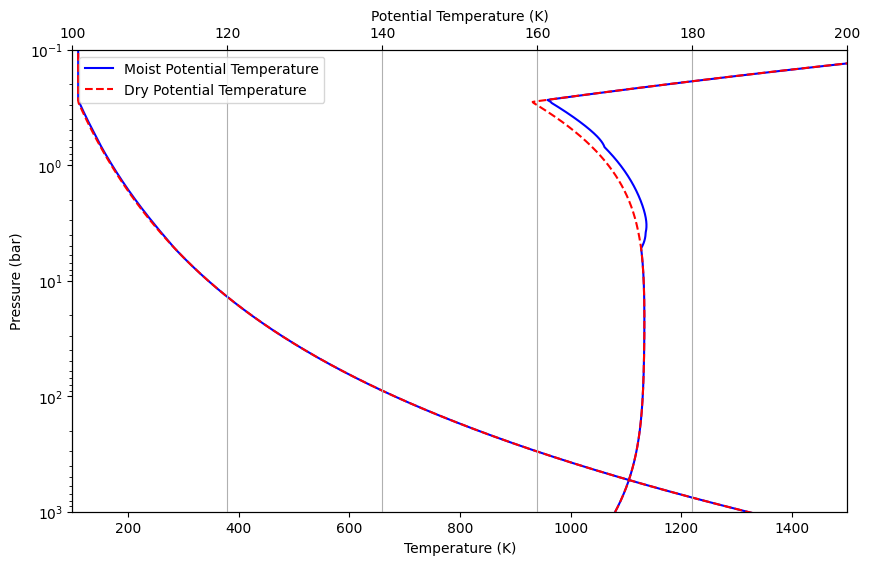

In [15]:
with h5py.File("juno_mwr_fwd_case-EZ-moist-main.nc", "r") as f:
    pressure = f["press"][0,:,0,0]*1E-5

# plot the temperature and potential temperature profiles
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(moist_temp, pressure, label='Moist Adiabatic', color='blue')
plt.plot(dry_temp, pressure, 'r--', label='Dry Adiabatic')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (bar)')

plt.yscale('log')
plt.ylim(1000,0.1)
plt.xlim(100,1500)

ax2 = plt.gca().twiny()
ax2.plot(moist_theta, pressure, label='Moist Potential Temperature', color='blue')
ax2.plot(dry_theta, pressure, 'r--', label='Dry Potential Temperature')
ax2.set_xlabel('Potential Temperature (K)')
ax2.set_xlim(100,200)


plt.legend()
plt.grid()
plt.show()


Number of bands: 6, Number of angles: 4


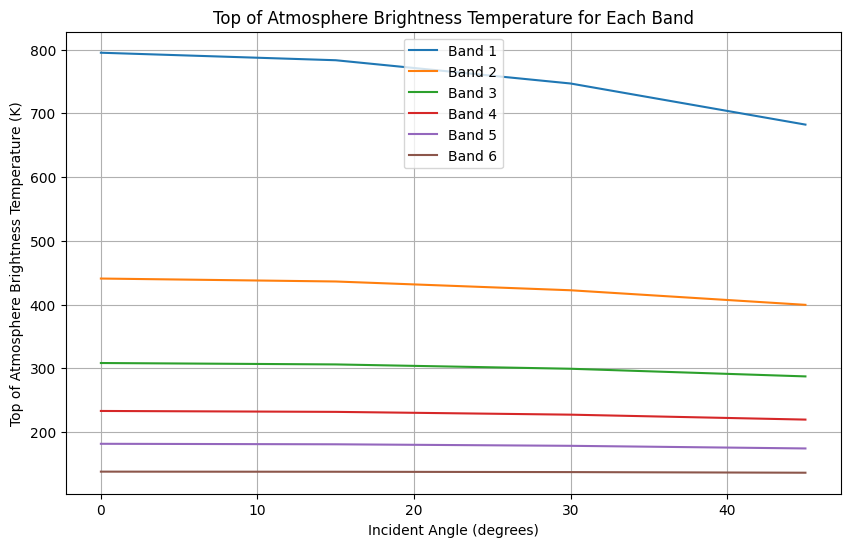

In [16]:
# get radance obj
rad = mb.get_rad()
nband = rad.get_num_bands()

# calculate the radiance for the Jindex_st column
rad.cal_radiance(mb, mb.k_st, mb.j_st + Jindex)
nray=len(angle)
tb =np.zeros((nband, nray))

print(f"Number of bands: {nband}, Number of angles: {nray}")

for ib in range(nband):
    toa = rad.get_band(ib).get_toa()[0]
    tb[ib, :] = toa

# plot the radiance for each band
plt.figure(figsize=(10, 6))
for ib in range(nband):
    plt.plot(angle, tb[ib, :], label=f'Band {ib+1}')
plt.xlabel('Incident Angle (degrees)')
plt.ylabel('Top of Atmosphere Brightness Temperature (K)')
plt.title('Top of Atmosphere Brightness Temperature for Each Band')
plt.legend()
plt.grid()
plt.show()
